# Dry Bean Classification - SVM
**Gray Interface '26 | Task 3 - Part 3**

Dataset: Dry Bean Dataset

## Importing the Dependencies

In [ ]:
!pip install kagglehub openpyxl seaborn --quiet


In [ ]:
import kagglehub
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)


## Loading the Dataset

In [ ]:
# Downloading the Dry Bean dataset from Kaggle
path = kagglehub.dataset_download("muratkokludataset/dry-bean-dataset")
print(os.listdir(path))

# Excel file is inside a subfolder
data_path = os.path.join(path, "Dry_Bean_Dataset", "Dry_Bean_Dataset.xlsx")
df = pd.read_excel(data_path)

print("Dataset Shape:", df.shape)
df.head()


Using Colab cache for faster access to the 'dry-bean-dataset' dataset.
['Dry_Bean_Dataset']
Dataset Shape: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


## Basic Dataset Information

In [ ]:
# Column names and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [ ]:
# Checking for missing values
df.isnull().sum()


,0
Area,0
Perimeter,0
MajorAxisLength,0
MinorAxisLength,0
AspectRation,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Solidity,0


In [ ]:
# Statistical summary
df.describe()


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [ ]:
# Class distribution of bean types
print(df['Class'].value_counts())


Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


## Exploratory Data Analysis

/tmp/ipykernel_848/4169044464.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, order=df['Class'].value_counts().index, palette='Set2')


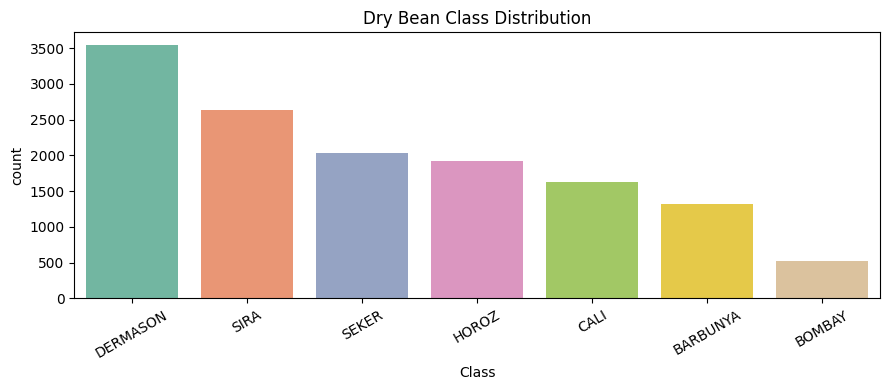

In [ ]:
# Bean class counts
plt.figure(figsize=(9, 4))
sns.countplot(x='Class', data=df, order=df['Class'].value_counts().index, palette='Set2')
plt.title('Dry Bean Class Distribution')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


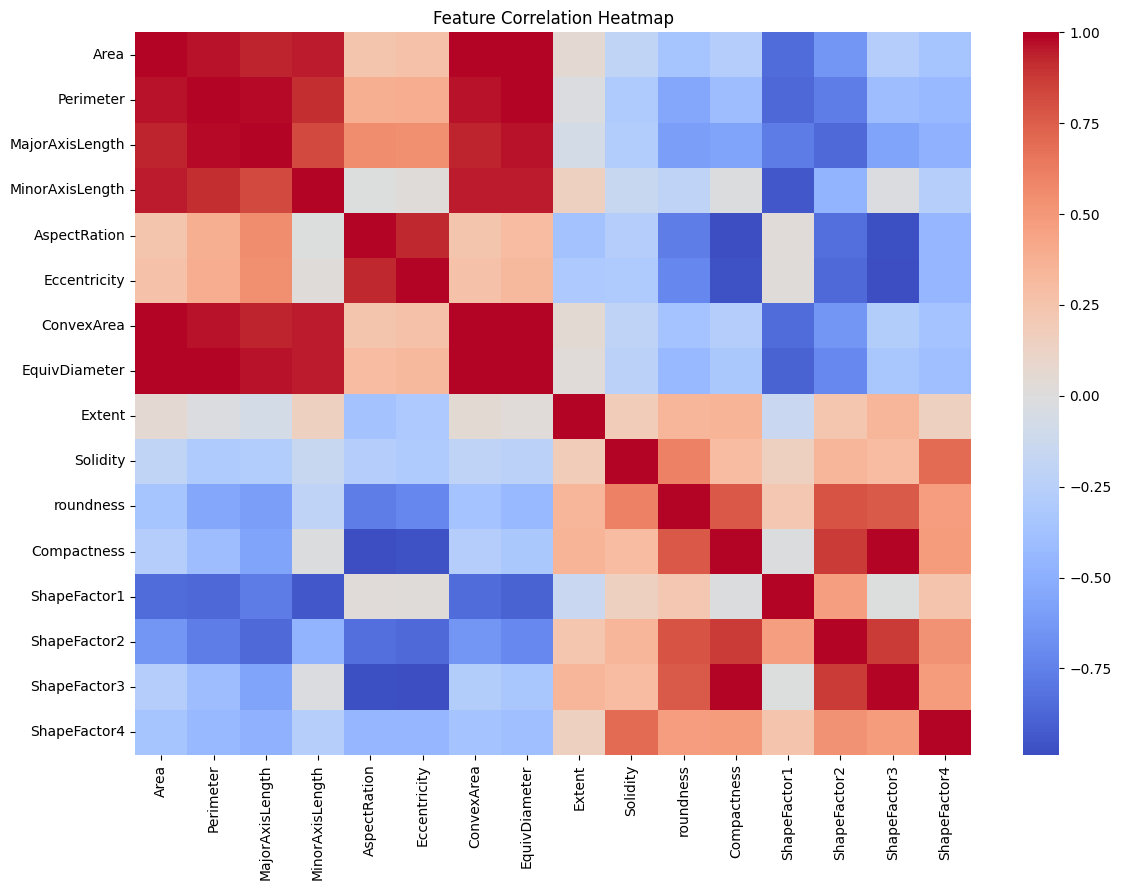

In [ ]:
# Correlation heatmap of numerical features
plt.figure(figsize=(12, 9))
sns.heatmap(df.drop(columns=['Class']).corr(), cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


## Observations so far
- No missing values
- 7 bean classes (multi-class problem)
- Some classes like DERMASON appear more often than BOMBAY
- Many shape features are correlated (Area, Perimeter, etc.)
- Feature scaling is important for SVM because it uses distances / margins


## Preprocessing

In [ ]:
# Features and target
X = df.drop(columns=['Class'])
Y = df['Class']

# Encoding class labels into numbers
le = LabelEncoder()
Y_enc = le.fit_transform(Y)
print("Classes:", list(le.classes_))

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y_enc, test_size=0.2, random_state=42, stratify=Y_enc
)
print(X_train.shape, X_test.shape)


Classes: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']
(10888, 16) (2723, 16)


In [ ]:
# Feature scaling (SVM is sensitive to feature scale)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
print("Scaled training data ready")


Scaled training data ready


## Helper Function for Evaluation

In [ ]:
def evaluate_svm(model, X_test, Y_test, name="Model", train_time=None):
    pred = model.predict(X_test)
    acc = accuracy_score(Y_test, pred)
    prec = precision_score(Y_test, pred, average='weighted')
    rec = recall_score(Y_test, pred, average='weighted')
    f1 = f1_score(Y_test, pred, average='weighted')

    print(f"===== {name} =====")
    if train_time is not None:
        print(f"Training time: {train_time:.2f} sec")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(Y_test, pred))
    print()
    return {
        'name': name,
        'train_time': train_time,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1
    }


## Comparing Kernels (and Training Time)

In [ ]:
# Train SVM with Linear, Polynomial, RBF and Sigmoid kernels
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
kernel_results = []

for kernel in kernels:
    model = SVC(kernel=kernel)
    start = time.time()
    model.fit(X_train_sc, Y_train)
    train_time = time.time() - start
    res = evaluate_svm(model, X_test_sc, Y_test, name=f"Kernel={kernel}", train_time=train_time)
    kernel_results.append(res)


===== Kernel=linear =====
Training time: 1.84 sec
Accuracy : 0.9221
Precision: 0.9222
Recall   : 0.9221
F1-Score : 0.9221
Confusion Matrix:
[[238   0  17   0   1   4   5]
 [  1 103   0   0   0   0   0]
 [  9   0 308   0   5   2   2]
 [  0   0   0 651   0  11  47]
 [  2   0   6   6 367   0   5]
 [  1   0   0   5   0 389  11]
 [  2   0   1  52   9   8 455]]

===== Kernel=poly =====
Training time: 3.31 sec
Accuracy : 0.9144
Precision: 0.9220
Recall   : 0.9144
F1-Score : 0.9159
Confusion Matrix:
[[223   0   9   0   1   2  30]
 [  0 103   1   0   0   0   0]
 [  6   0 304   0   6   2   8]
 [  0   0   0 622   0   7  80]
 [  2   0   4   5 364   0  11]
 [  2   0   0   7   0 380  17]
 [  0   0   0  23   7   3 494]]

===== Kernel=rbf =====
Training time: 1.61 sec
Accuracy : 0.9221
Precision: 0.9224
Recall   : 0.9221
F1-Score : 0.9222
Confusion Matrix:
[[236   0  18   0   1   4   6]
 [  0 104   0   0   0   0   0]
 [  7   0 309   0   6   2   2]
 [  0   0   0 647   0  13  49]
 [  1   0   4   5 370  

In [ ]:
kernel_df = pd.DataFrame(kernel_results).sort_values('f1', ascending=False)
kernel_df


,name,train_time,accuracy,precision,recall,f1
2,Kernel=rbf,1.609856,0.922145,0.922426,0.922145,0.922177
0,Kernel=linear,1.843599,0.922145,0.922227,0.922145,0.922107
1,Kernel=poly,3.313461,0.914433,0.921983,0.914433,0.915887
3,Kernel=sigmoid,1.379783,0.729343,0.761113,0.729343,0.742985


## Experimenting with C and Gamma (RBF)

In [ ]:
# C controls how much we penalize misclassification
# gamma controls how far the influence of a single training example reaches
C_values = [0.1, 1, 10]
gamma_values = ['scale', 0.01, 0.1, 1]

rbf_results = []
for C in C_values:
    for gamma in gamma_values:
        model = SVC(kernel='rbf', C=C, gamma=gamma)
        start = time.time()
        model.fit(X_train_sc, Y_train)
        train_time = time.time() - start
        res = evaluate_svm(
            model, X_test_sc, Y_test,
            name=f"RBF | C={C}, gamma={gamma}",
            train_time=train_time
        )
        rbf_results.append(res)


===== RBF | C=0.1, gamma=scale =====
Training time: 1.15 sec
Accuracy : 0.9199
Precision: 0.9212
Recall   : 0.9199
F1-Score : 0.9201
Confusion Matrix:
[[227   0  23   0   1   4  10]
 [  0 104   0   0   0   0   0]
 [  5   0 308   0   7   2   4]
 [  0   0   0 644   0  13  52]
 [  0   0   5   5 370   0   6]
 [  1   0   0   6   0 384  15]
 [  2   0   0  42   9   6 468]]

===== RBF | C=0.1, gamma=0.01 =====
Training time: 1.92 sec
Accuracy : 0.9126
Precision: 0.9153
Recall   : 0.9126
F1-Score : 0.9130
Confusion Matrix:
[[222   0  26   0   1   2  14]
 [  0 104   0   0   0   0   0]
 [  3   0 310   0   5   2   6]
 [  0   0   0 635   0  15  59]
 [  0   0   7   4 366   0   9]
 [  3   0   0   6   0 380  17]
 [  0   0   1  45   9   4 468]]

===== RBF | C=0.1, gamma=0.1 =====
Training time: 1.43 sec
Accuracy : 0.9214
Precision: 0.9224
Recall   : 0.9214
F1-Score : 0.9215
Confusion Matrix:
[[229   0  23   0   1   4   8]
 [  0 103   0   0   1   0   0]
 [  5   0 309   0   7   2   3]
 [  0   0   0 646  

In [ ]:
rbf_df = pd.DataFrame(rbf_results).sort_values('f1', ascending=False)
rbf_df.head(10)


## Experimenting with Degree (Polynomial Kernel)

In [ ]:
# Degree controls complexity of the polynomial decision boundary
degree_values = [2, 3, 4]
poly_results = []

for degree in degree_values:
    for C in [0.1, 1, 10]:
        model = SVC(kernel='poly', degree=degree, C=C)
        start = time.time()
        model.fit(X_train_sc, Y_train)
        train_time = time.time() - start
        res = evaluate_svm(
            model, X_test_sc, Y_test,
            name=f"Poly | degree={degree}, C={C}",
            train_time=train_time
        )
        poly_results.append(res)


===== Poly | degree=2, C=0.1 =====
Training time: 1.92 sec
Accuracy : 0.8505
Precision: 0.8674
Recall   : 0.8505
F1-Score : 0.8492
Confusion Matrix:
[[173   0   2  47   2   2  39]
 [  0 104   0   0   0   0   0]
 [  1   0 205 100   3   4  13]
 [  0   0   7 609   0   7  86]
 [  0   0   2   7 359   4  14]
 [  0   0   3   8   1 375  19]
 [  0   0   2  24   7   3 491]]

===== Poly | degree=2, C=1 =====
Training time: 1.18 sec
Accuracy : 0.9133
Precision: 0.9169
Recall   : 0.9133
F1-Score : 0.9140
Confusion Matrix:
[[223   0  12   4   1   2  23]
 [  0 104   0   0   0   0   0]
 [  5   0 298   8   6   2   7]
 [  0   0   4 634   0  11  60]
 [  0   0   3   7 367   1   8]
 [  2   0   0   6   0 381  17]
 [  1   0   1  35   7   3 480]]

===== Poly | degree=2, C=10 =====
Training time: 1.35 sec
Accuracy : 0.9214
Precision: 0.9227
Recall   : 0.9214
F1-Score : 0.9218
Confusion Matrix:
[[236   0  15   0   1   3  10]
 [  0 103   1   0   0   0   0]
 [  9   0 305   0   6   2   4]
 [  0   0   0 645   0  10

In [ ]:
poly_df = pd.DataFrame(poly_results).sort_values('f1', ascending=False)
poly_df


,name,train_time,accuracy,precision,recall,f1
2,"Poly | degree=2, C=10",1.350428,0.921410,0.922745,0.921410,0.921806
5,"Poly | degree=3, C=10",0.628688,0.919941,0.921918,0.919941,0.920413
4,"Poly | degree=3, C=1",0.803921,0.914433,0.921983,0.914433,0.915887
1,"Poly | degree=2, C=1",1.178808,0.913331,0.916892,0.913331,0.914030
8,"Poly | degree=4, C=10",1.166563,0.908924,0.916420,0.908924,0.910263
3,"Poly | degree=3, C=0.1",2.460271,0.872567,0.901223,0.872567,0.876749
7,"Poly | degree=4, C=1",1.551449,0.863386,0.883613,0.863386,0.865090
0,"Poly | degree=2, C=0.1",1.920246,0.850533,0.867360,0.850533,0.849218
6,"Poly | degree=4, C=0.1",2.500315,0.774881,0.831570,0.774881,0.776203


## Best Model Summary

In [ ]:
# Combine all experiment results and pick the best by F1
all_df = pd.concat([
    kernel_df,
    rbf_df,
    poly_df
], ignore_index=True).sort_values('f1', ascending=False)

all_df.head(10)


,name,train_time,accuracy,precision,recall,f1
4,"RBF | C=10, gamma=0.1",0.795381,0.927286,0.927227,0.927286,0.927198
5,"RBF | C=1, gamma=0.1",0.731321,0.924715,0.924877,0.924715,0.924713
6,"RBF | C=10, gamma=scale",1.223844,0.924348,0.924320,0.924348,0.924295
7,"RBF | C=10, gamma=0.01",0.723211,0.922879,0.923017,0.922879,0.922896
0,Kernel=rbf,1.609856,0.922145,0.922426,0.922145,0.922177
8,"RBF | C=1, gamma=scale",0.718111,0.922145,0.922426,0.922145,0.922177
1,Kernel=linear,1.843599,0.922145,0.922227,0.922145,0.922107
16,"Poly | degree=2, C=10",1.350428,0.921410,0.922745,0.921410,0.921806
9,"RBF | C=0.1, gamma=0.1",1.432914,0.921410,0.922428,0.921410,0.921532
10,"RBF | C=1, gamma=0.01",0.880306,0.920308,0.921178,0.920308,0.920475


In [ ]:
# Retrain a strong model for a clean classification report
# (Update these values based on the best row above if needed)
best_model = SVC(kernel='rbf', C=10, gamma='scale')
best_model.fit(X_train_sc, Y_train)
best_pred = best_model.predict(X_test_sc)

print(classification_report(Y_test, best_pred, target_names=le.classes_))
print("Confusion Matrix:")
print(confusion_matrix(Y_test, best_pred))


              precision    recall  f1-score   support

    BARBUNYA       0.93      0.91      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.91      0.92      0.92       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.94      0.95      0.95       406
        SIRA       0.87      0.86      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.92      0.92      0.92      2723

Confusion Matrix:
[[241   0  16   0   0   3   5]
 [  0 104   0   0   0   0   0]
 [ 10   0 307   0   6   2   1]
 [  0   0   0 655   0  11  43]
 [  1   0   4   6 369   0   6]
 [  3   0   0   6   0 386  11]
 [  3   0   0  53   9   7 455]]


## Key Findings

| # | Finding |
|---|---------|
| 1 | Feature scaling is important for SVM because kernels depend on feature magnitudes |
| 2 | Linear and RBF usually do well on this dataset; Sigmoid is often weaker |
| 3 | RBF is flexible and often gives the best accuracy/F1 after tuning C and gamma |
| 4 | Higher C fits training data more strictly; too high can overfit |
| 5 | Polynomial degree increases complexity; higher degree is not always better |
| 6 | Training time differs by kernel — Linear is often faster than RBF/Poly |
